**Table of contents**<a id='toc0_'></a>    
- [Simulation output 4 fluorophores with ET (and photobleaching)](#toc1_)    
  - [Transition set](#toc1_1_)    
  - [Data generation](#toc1_2_)    
    - [Simulation](#toc1_2_1_)    
    - [Save the data](#toc1_2_2_)    
  - [Data processing and visualization](#toc1_3_)    
    - [Read the data](#toc1_3_1_)    
    - [Post-processing](#toc1_3_2_)    
    - [Figure](#toc1_3_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Simulation output 4 fluorophores with ET (and photobleaching)](#toc0_)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

import fluopy.analysis as an
import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.fluorophores as fl
import fluopy.miscellaneous as mi
import fluopy.routines as rt
import fluopy.simulation as si
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

saving_at = (
    r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_10_multi_f_et_statistics"
)

## <a id='toc1_1_'></a>[Transition set](#toc0_)

In [3]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=3, count=4, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    bleaching=True,
    energy_transfer=True,
    **rt.PARAMS_DSTORM,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

## <a id='toc1_2_'></a>[Data generation](#toc0_)

### <a id='toc1_2_1_'></a>[Simulation](#toc0_)

In [ ]:
rng = np.random.default_rng(1)

simulation = si.Simulation(transition_set)
simulation.run(size=1e6, end_time=10000, seed=rng, use_memmap=saving_at)

WARNING for line:         warnings.warn(
 Floating point precision error warning:
 The smallest safe increment is 1.82e-12.
 Everything drawn below this number might be rounded to zero
 when approaching the time limit of this simulation.
 Using the highest possible rate which occurs for example in state combination [1, 1, 1, 1]
 gives a probability of 8.50e-01 for a smaller increment to be drawn. 


### <a id='toc1_2_2_'></a>[Save the data](#toc0_)

In [ ]:
# the simulation is saved in the memmap file
# reading memmap files require shape
shape_state_series = simulation.state_series.shape
shape_transition_series = simulation.transition_series.shape
shape_time_series = simulation.time_series.shape
print(f"state_series shape: {shape_state_series}")
print(f"transition_series shape: {shape_transition_series}")
print(f"time_series shape: {shape_time_series}")

state_series shape: (4, 540349840)
transition_series shape: (540349839,)
time_series shape: (540349841,)


## <a id='toc1_3_'></a>[Data processing and visualization](#toc0_)

### <a id='toc1_3_1_'></a>[Read the data](#toc0_)

In [4]:
shape_state_series = (4, 540349840)
shape_transition_series = (540349839,)
shape_time_series = (540349841,)
simulation = si.Simulation(transition_set)
simulation.state_series = np.memmap(
    saving_at + r"\state_series",
    dtype=np.int8,
    mode="r",
    shape=shape_state_series,
)
simulation.transition_series = np.memmap(
    saving_at + r"\transition_series",
    dtype=np.uint32,
    mode="r",
    shape=shape_transition_series,
)
simulation.time_series = np.memmap(
    saving_at + r"\time_series",
    dtype=np.float64,
    mode="r",
    shape=shape_time_series,
)

### <a id='toc1_3_2_'></a>[Post-processing](#toc0_)

In [5]:
rng = np.random.default_rng(1)
analysis = an.Analysis(simulation)

emis = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis.extract(simulation)
rt.emission_post_processing(emis=emis, seed=rng)

fcs = fcs_p.FCS(emis)
fcs.autocorrelate_time_points(
    exp_min=-10, exp_max=-4, points_per_base=4, base=10, normalize=True
)

blink = bl.Blinking(emis)
copy_on_periods = blink.on_periods.copy()

if a fluorophore reaches its individual absorbing state, it has an absolute state and transition frequency of 1, but the lifetime is nan and the state occupation 0.


fluorophore 0 has reached the Markovian absorbing state SingleState.B
fluorophore 1 has reached the Markovian absorbing state SingleState.B
fluorophore 2 has reached the Markovian absorbing state SingleState.B
fluorophore 3 has reached the Markovian absorbing state SingleState.B


### <a id='toc1_3_3_'></a>[Figure](#toc0_)

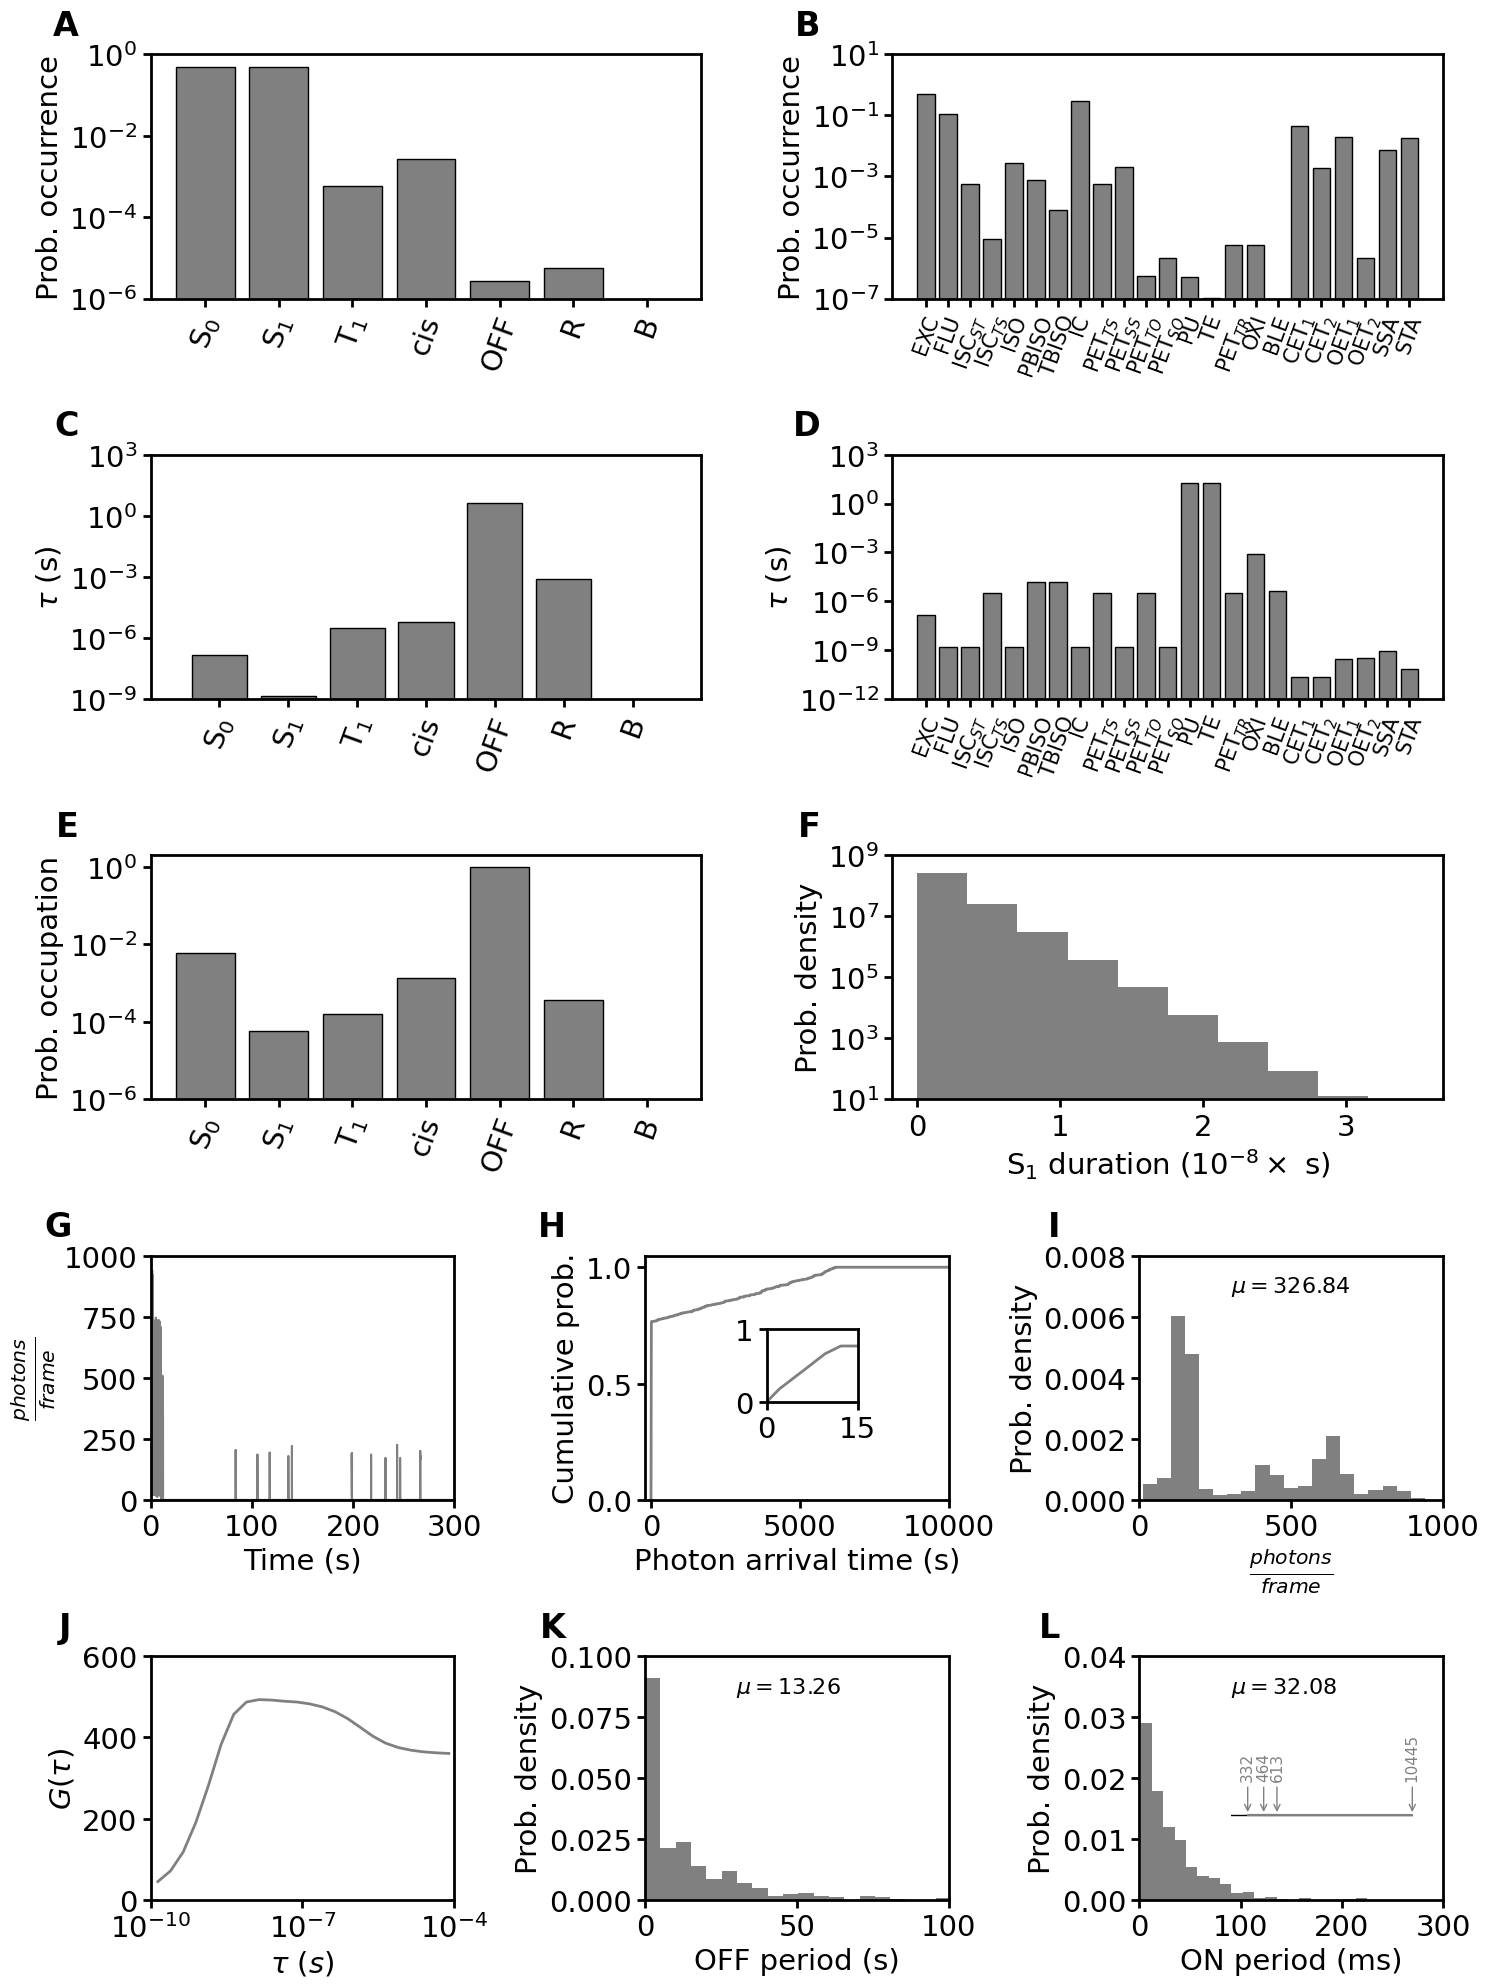

In [7]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(5, 6)
fig = plt.figure(figsize=(15, 20))
color = "grey"
analysis_plot_param = dict(legend=False, color=color)
ax = fig.add_subplot(gs[0, 0:3])
analysis.plot_frequency_states(ylim=[1e-6, 1e0], axes=ax, **analysis_plot_param)
ax = fig.add_subplot(gs[0, 3:])
analysis.plot_frequency_transitions(
    ylim=[1e-7, 1e1],
    axes=ax,
    diff_dist=False,
    **analysis_plot_param,
    yticks=[1e-7, 1e-5, 1e-3, 1e-1, 1e1],
)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=15)
ax = fig.add_subplot(gs[1, 0:3])
analysis.plot_mean_lifetimes(ylim=[1e-9, 1e3], axes=ax, **analysis_plot_param)
ax = fig.add_subplot(gs[1, 3:])
analysis.plot_mean_transition_times(
    ylim=[1e-12, 1e3],
    axes=ax,
    diff_dist=False,
    **analysis_plot_param,
    yticks=[1e-12, 1e-9, 1e-6, 1e-3, 1e0, 1e3],
)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=15)

ax = fig.add_subplot(gs[2, 0:3])
analysis.plot_state_occupations(ylim=[1e-6, 2e0], axes=ax, **analysis_plot_param)
ax = fig.add_subplot(gs[2, 3:])
analysis.plot_lifetime_distributions(
    state_identity=1,
    axes=ax,
    fluorophore="cy5_dna",
    **analysis_plot_param,
    title=None,
    ylim=[1e1, 1e9],
    tick_style_x="sci",
)


ax = fig.add_subplot(gs[3, 0:2])
emis.plot_time_series(axes=ax, color=color, xlim=[0, 300], ylim=[0, 1000])
ax = fig.add_subplot(gs[3, 2:4])
emis.plot_cumulative_events(
    axes=ax,
    color=color,
    xlim=[-200, 10000],
    ylim=[0, 1.05],
    lw=2,
)
inset = ax.inset_axes(
    [0.4, 0.4, 0.3, 0.3],
)
emis.plot_cumulative_events(
    axes=inset,
    color=color,
    lw=2,
    xlim=[0, 15],
    ylim=[0, 1],
    ylabel="",
    xlabel="",
)
inset.set_xticks([0, 15])

ax = fig.add_subplot(gs[3, 4:])
emis.plot_histogram(
    axes=ax,
    color=color,
    ylim=[0, 0.008],
    xlim=[0, 1000],
    display_mean=True,
    bins=20,
)


ax = fig.add_subplot(gs[4, 0:2])
fcs.plot(
    axes=ax,
    unit="s",
    color=color,
    title=None,
    xlim=[1e-10, 1e-4],
    ylim=[0, 600],
    lw=2,
)
ax = fig.add_subplot(gs[4, 2:4])
blink.plot(
    mode="off_histogram",
    axes=ax,
    as_time="s",
    color=color,
    xlim=[0, 100],
    ylim=[0, 0.1],
    bins=20,
)
ax = fig.add_subplot(gs[4, 4:])
# MODIFICATION OF DATA!
blink.on_periods = blink.on_periods[blink.on_periods < 300]
blink.plot(
    mode="on_histogram",
    axes=ax,
    as_time="ms",
    color=color,
    xlim=[0, 300],
    ylim=[0, 0.04],
    bins=20,
)
inset = ax.inset_axes(
    [0.3, 0.1, 0.6, 0.5],
)
inset.axhline(0, color="black", lw=1)
outliers = copy_on_periods[copy_on_periods > 300]
inset.plot(outliers, np.zeros_like(outliers), marker="", color="grey")
inset.set_xlim([min(outliers) - 100, max(outliers) + 100])
inset.set_xscale("log")
inset.axis("off")
for outlier in outliers:
    inset.annotate(
        f"{outlier}",
        xy=(outlier, 0),
        xytext=(outlier, 0.03),
        textcoords="data",
        ha="center",
        va="bottom",
        arrowprops=dict(arrowstyle="->", color="grey"),
        fontsize=11,
        color="grey",
        rotation=90,
    )

axes = fig.get_axes()
for i, (axis, letter) in enumerate(
    zip(axes, ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L"])
):
    offset = -0.13
    if i > 5:
        offset = -0.26
    axis.text(
        offset,
        1.05,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
fig.tight_layout()
bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)
fig.savefig(saving_at + r"\4_f_et_statistics.png", bbox_inches=bbox, dpi=300)